# Hart Trophy MVP Prediction: A Modern Analytical Approach

**Original analysis:** 2017–2018 grad school project  
**Modern reimagining:** Using today's ML best practices on the same dataset

---

## Abstract

This notebook revisits an NHL Hart Memorial Trophy prediction analysis originally written as a learning exercise in graduate school. The original work correctly identified the problem, found a good dataset, and built functional code — but made several methodological errors that are now textbook examples in data science pedagogy.

This notebook does three things:
1. **Critiques** the original analysis fairly and specifically, reproducing its failure modes in code
2. **Corrects** each flaw with the corresponding modern best practice
3. **Implements** a modern prediction pipeline using regularized regression and gradient boosting with full explainability

The same dataset (`NHL.csv`, player stats 2004–2018) is used throughout — no external data sources required.

### Why this problem is hard

The Hart Trophy is awarded annually by the Professional Hockey Writers' Association to the player "adjudged to be the most valuable to his team." With ~800 eligible players per season and exactly one winner, any binary classifier trivially achieves 99.9% accuracy by predicting nobody wins. The original analysis fell into exactly this trap. The correct framing: **predict vote share** (a continuous ranking target), then evaluate whether the top-predicted player matches the actual winner.

---
## Contents

0. [Introduction](#intro)
1. [Imports & Setup](#imports)
2. [Data Loading & Cleaning](#data)
3. [Exploratory Data Analysis](#eda)
4. [Feature Engineering](#features)
5. [Baseline Models](#baseline)
6. [Regularized Linear Regression (Ridge & Lasso)](#linear)
7. [XGBoost with SHAP Explainability](#xgb)
8. [Comprehensive Evaluation](#eval)
9. [Critique of the Original Analysis](#critique)
10. [What More Data Would Enable](#moredata)
11. [Conclusions](#conclusions)

## 1. Imports & Setup

In [1]:
# Uncomment to install if needed:
# !pip install xgboost shap plotly statsmodels -q

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, LogisticRegression, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix

import xgboost as xgb
import shap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
print("All imports successful.")

All imports successful.


## 2. Data Loading & Cleaning

The CSV has several quirks that need handling before any analysis:

| Issue | Symptom | Fix |
|-------|---------|-----|
| Duplicate column names | `EV`, `PP`, `SH` appear twice (goals then assists) | Rename at load time |
| Corrupted ATOI | Brent Burns shows `0.87` instead of `24.87` | Recompute as `TOI / GP` |
| 2009 data duplication | 882 extra rows from a mislabeled earlier season | Drop rows where `HIT==0 & Votes==0 & Season==2009` |
| Incomplete 2018 season | 28 games played, zero votes recorded | Exclude entirely |
| Missing S% | 101 players with 0 shots have `NaN` shot percentage | Fill with `0.0` |

In [2]:
# Supply correct column names to resolve the EV/PP/SH duplicate collision
COL_NAMES = [
    'Rk', 'Player', 'Age', 'Pos', 'Tm', 'GP', 'G', 'A', 'PTS', 'plusminus',
    'PIM', 'PS', 'EV_G', 'PP_G', 'SH_G', 'GW', 'EV_A', 'PP_A', 'SH_A',
    'S', 'S_percent', 'TOI', 'ATOI_raw', 'BLK', 'HIT', 'FOW', 'FOL',
    'FO_percent', 'HART', 'Votes', 'Season'
]

df_raw = pd.read_csv('NHL.csv', encoding='latin-1', names=COL_NAMES, header=0)
print(f"Raw shape: {df_raw.shape}")
print(f"Seasons present: {sorted(df_raw['Season'].unique())}")
print(f"Total HART winners: {df_raw['HART'].sum()}")

Raw shape: (13056, 31)
Seasons present: [np.int64(2004), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Total HART winners: 13


In [3]:
# ── Step 1: Drop 2018 (incomplete, zero votes) ──────────────────────────────
df = df_raw[df_raw['Season'] != 2018].copy()
print(f"After dropping 2018: {df.shape[0]} rows")

# ── Step 2: Remove 2009 duplicate rows ──────────────────────────────────────
# These are rows from an earlier season mislabeled as 2009.
# Signature: Season==2009 AND HIT==0 AND Votes==0
# (All legitimate 2009 rows have HIT > 0 because 2009 was the first season
#  with hits tracked; the only exception would be a player with votes, which
#  the filter also preserves.)
mask_2009_junk = (df['Season'] == 2009) & (df['HIT'] == 0) & (df['Votes'] == 0)
print(f"2009 junk rows to remove: {mask_2009_junk.sum()}")
df = df[~mask_2009_junk].copy()
print(f"After 2009 fix: {df.shape[0]} rows")

# ── Step 3: Fix S_percent (NaN when shots = 0) ──────────────────────────────
df['S_percent'] = df['S_percent'].fillna(0.0)

# ── Step 4: Recompute ATOI from TOI / GP ────────────────────────────────────
# The original ATOI column is corrupted for high-minute defensemen.
# Brent Burns (2017): ATOI_raw=0.87, correct value=2039/82=24.87
df['ATOI'] = df['TOI'] / df['GP']
df = df.drop(columns=['ATOI_raw'])

# ── Step 5: Parse positions ──────────────────────────────────────────────────
df['Pos_clean'] = df['Pos'].str.split('/').str[0]
df['is_forward'] = (df['Pos_clean'] != 'D').astype(int)

# ── Step 6: Clean player name (remove hockey-reference ID suffix) ────────────
df['Name'] = df['Player'].str.split('\\').str[0]

# ── Step 7: Vote share target ────────────────────────────────────────────────
# Raw vote totals vary by season (1,665 in 2004 → 4,254 in 2013).
# Normalize within season to make the target comparable across seasons.
season_total = df.groupby('Season')['Votes'].transform('sum')
df['vote_share'] = df['Votes'] / season_total

print(f"\nFinal shape: {df.shape}")
print(f"Seasons: {sorted(df['Season'].unique())}")
print(f"HART winners: {df['HART'].sum()}")
print(f"\nBrent Burns ATOI (corrected): {df[(df['Name'].str.contains('Burns')) & (df['Season']==2017)]['ATOI'].values[0]:.2f} min/game")

After dropping 2018: 12296 rows
2009 junk rows to remove: 882
After 2009 fix: 11414 rows

Final shape: (11414, 35)
Seasons: [np.int64(2004), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]
HART winners: 13

Brent Burns ATOI (corrected): 24.87 min/game


In [4]:
# Verify Hart winners
print("Hart Trophy winners in dataset:")
winners = df[df['HART'] == 1][['Season', 'Name', 'G', 'A', 'PTS', 'Votes', 'vote_share']].sort_values('Season')
print(winners.to_string(index=False))

Hart Trophy winners in dataset:
 Season             Name  G  A  PTS  Votes  vote_share
   2004 Martin St. Louis 38 56   94   1016      0.6102
   2006     Joe Thornton 29 96  125   1058      0.4379
   2007    Sidney Crosby 36 84  120   1225      0.6475
   2008    Alex Ovechkin 65 47  112   1313      0.4231
   2009    Alex Ovechkin 56 54  110   1264      0.4327
   2010     Henrik Sedin 29 83  112    894      0.3546
   2011      Corey Perry 50 48   98   1043      0.3951
   2012    Evgeni Malkin 50 59  109   1473      0.5274
   2013    Alex Ovechkin 32 24   56   1090      0.2562
   2014    Sidney Crosby 36 68  104   1340      0.4296
   2015    Alex Ovechkin 53 28   81    888      0.4249
   2016     Patrick Kane 46 60  106   1395      0.4074
   2017   Connor McDavid 30 70  100   1604      0.4212


## 3. Exploratory Data Analysis

Before modeling, we need to understand why the original approach was structurally flawed — and visualize what we're actually working with.

### 3.1 The Class Imbalance Problem

In [5]:
# The fundamental problem with the original binary classification approach
hart_counts = df['HART'].value_counts().sort_index()
ratio = hart_counts[0] / hart_counts[1]

fig = make_subplots(rows=1, cols=2,
    subplot_titles=[
        f'Binary HART target: {ratio:.0f}:1 class imbalance',
        'Vote share distribution (log scale, vote-getters only)'
    ])

fig.add_trace(go.Bar(
    x=['Non-winners (HART=0)', 'Hart Winners (HART=1)'],
    y=[hart_counts[0], hart_counts[1]],
    marker_color=['#4472C4', '#ED7D31'],
    text=[f'{hart_counts[0]:,}', f'{hart_counts[1]}'],
    textposition='outside'
), row=1, col=1)

vote_getters = df[df['vote_share'] > 0]['vote_share']
fig.add_trace(go.Histogram(
    x=np.log10(vote_getters),
    nbinsx=35,
    marker_color='#4472C4',
    opacity=0.8
), row=1, col=2)

fig.update_layout(
    title_text="Why Binary Classification Fails: The Class Imbalance Trap",
    showlegend=False,
    height=400
)
fig.update_xaxes(title_text="log₁₀(vote share)", row=1, col=2)
fig.update_yaxes(title_text="Player-seasons", row=1, col=1)
fig.show()

print(f"Class imbalance ratio: {ratio:.0f}:1")
print(f"A model that predicts 'nobody wins' every time achieves {hart_counts[0]/hart_counts.sum()*100:.1f}% accuracy.")
print("This is exactly the 99.9% the original reported — with ZERO true positives.")

Class imbalance ratio: 877:1
A model that predicts 'nobody wins' every time achieves 99.9% accuracy.
This is exactly the 99.9% the original reported — with ZERO true positives.


### 3.2 Where Hart Winners Sit in the Distribution

In [6]:
# Compare Hart winners vs. all players on key metrics
winners_df = df[df['HART'] == 1]
others_df  = df[df['HART'] == 0]

metrics = ['PTS', 'G', 'PS', 'ATOI', 'S']
fig = make_subplots(rows=1, cols=len(metrics), subplot_titles=metrics,
                    shared_yaxes=False)

for i, metric in enumerate(metrics, 1):
    # All players as violin
    fig.add_trace(go.Violin(
        y=others_df[metric], name='Non-winners',
        line_color='#4472C4', fillcolor='rgba(68,114,196,0.3)',
        showlegend=(i == 1), side='positive', width=1.8
    ), row=1, col=i)
    # Winners as red stars
    fig.add_trace(go.Scatter(
        x=[0] * len(winners_df), y=winners_df[metric],
        mode='markers+text',
        marker=dict(color='#ED7D31', size=12, symbol='star',
                    line=dict(color='black', width=1)),
        text=winners_df['Season'].astype(str),
        textposition='middle right',
        textfont=dict(size=8),
        name='Hart Winner', showlegend=(i == 1)
    ), row=1, col=i)

fig.update_layout(
    title="Hart Winners vs All Players — Key Statistics",
    height=500,
    legend=dict(orientation='h', y=-0.15)
)
fig.show()

### 3.3 Multicollinearity: The Original's Hidden Problem

In [7]:
# The original analysis used G, A, PTS, EV_G, PP_G, EV_A, PP_A simultaneously.
# These are perfectly collinear by construction.

print("=== Perfect Multicollinearity Checks ===")
print(f"PTS == G + A (always):              {(df['PTS'] == df['G'] + df['A']).all()}")
print(f"EV_G + PP_G + SH_G == G (always):   {(df['EV_G'] + df['PP_G'] + df['SH_G'] == df['G']).all()}")
print(f"EV_A + PP_A + SH_A == A (always):   {(df['EV_A'] + df['PP_A'] + df['SH_A'] == df['A']).all()}")

print("\nUsing G, A, PTS, EV_G, PP_G, EV_A, PP_A together is perfectly collinear.")
print("The original regression coefficients are undefined (infinite solutions exist).")
print("sklearn silently picks one arbitrary solution via pseudoinverse — meaningless.")

=== Perfect Multicollinearity Checks ===
PTS == G + A (always):              True
EV_G + PP_G + SH_G == G (always):   True
EV_A + PP_A + SH_A == A (always):   False

Using G, A, PTS, EV_G, PP_G, EV_A, PP_A together is perfectly collinear.
The original regression coefficients are undefined (infinite solutions exist).
sklearn silently picks one arbitrary solution via pseudoinverse — meaningless.


In [8]:
# VIF analysis on the original feature set
orig_vif_cols = ['G', 'A', 'PTS', 'EV_G', 'PP_G', 'EV_A', 'PP_A', 'S', 'PS', 'TOI', 'GP']
vif_data = df[orig_vif_cols].dropna().replace([np.inf, -np.inf], np.nan).dropna()
X_vif = add_constant(vif_data.values)

vif_rows = []
for i, col in enumerate(orig_vif_cols):
    try:
        v = variance_inflation_factor(X_vif, i + 1)
    except:
        v = np.inf
    vif_rows.append({'Feature': col, 'VIF': v})

vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)

fig = px.bar(
    vif_df,
    x='VIF', y='Feature',
    orientation='h',
    color='VIF',
    color_continuous_scale='Reds',
    title='Variance Inflation Factor — Original Feature Set<br><sup>VIF > 10 = severe multicollinearity; VIF > 5 = moderate</sup>',
    labels={'VIF': 'VIF Score'},
)
fig.add_vline(x=10, line_dash='dash', line_color='red', annotation_text='VIF=10 threshold')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, showlegend=False, height=450)
fig.show()

print("\nFeatures with VIF > 100 (extreme multicollinearity):")
print(vif_df[vif_df['VIF'] > 100][['Feature', 'VIF']].to_string(index=False))


Features with VIF > 100 (extreme multicollinearity):
Feature      VIF
      G      inf
      A      inf
    PTS      inf
   EV_A 229.4578
   EV_G 113.2866
   PP_A 108.6756


### 3.4 Correlation Heatmap

In [9]:
corr_cols = ['G', 'A', 'PTS', 'EV_G', 'PP_G', 'EV_A', 'PP_A', 'S', 'PS', 'ATOI', 'vote_share']
corr_matrix = df[corr_cols].corr()

fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Correlation Matrix — Note the near-1.0 values between G, A, PTS and their components'
)
fig.update_layout(height=500)
fig.show()

print("\nCorrelation with vote_share (target):")
print(corr_matrix['vote_share'].sort_values(ascending=False).to_string())


Correlation with vote_share (target):
vote_share   1.0000
PTS          0.2207
G            0.2200
PS           0.2189
EV_G         0.2074
A            0.2011
PP_G         0.1977
PP_A         0.1925
EV_A         0.1810
S            0.1655
ATOI         0.0769


### 3.5 Season-by-Season Vote Landscape (Interactive)

In [10]:
seasons_list = sorted(df['Season'].unique())

fig = go.Figure()
for s_idx, season in enumerate(seasons_list):
    s_data = df[df['Season'] == season].nlargest(10, 'Votes').sort_values('Votes')
    visible = (season == 2017)
    colors = ['#ED7D31' if h else '#4472C4' for h in s_data['HART']]
    hover = [f"{n}<br>{pts} PTS, {g} G<br>{votes} votes"
             for n, pts, g, votes in zip(s_data['Name'], s_data['PTS'], s_data['G'], s_data['Votes'])]
    fig.add_trace(go.Bar(
        y=s_data['Name'],
        x=s_data['Votes'],
        orientation='h',
        marker_color=colors,
        hovertext=hover,
        hoverinfo='text',
        visible=visible,
        name=str(season)
    ))

buttons = []
for i, season in enumerate(seasons_list):
    visible_arr = [j == i for j in range(len(seasons_list))]
    buttons.append(dict(
        label=str(season),
        method='update',
        args=[{'visible': visible_arr},
              {'title': f'{season} Hart Trophy: Top 10 Vote-Getters (orange = winner)'}]
    ))

fig.update_layout(
    updatemenus=[dict(active=len(seasons_list)-1, buttons=buttons,
                      x=1.02, y=1.1, xanchor='left')],
    title='2017 Hart Trophy: Top 10 Vote-Getters (orange = winner)',
    xaxis_title='Total Votes',
    height=420,
    margin=dict(l=140)
)
fig.show()

## 4. Feature Engineering

Three tiers of features, each addressing a different limitation of the original:

| Tier | What it fixes | Examples |
|------|--------------|---------|
| **Per-game rate stats** | Raw totals biased toward more games played; 2013 lockout (48 games) vs normal (82 games) | `G_per_GP`, `PTS_per_GP` |
| **Season z-scores** | Cross-season comparability; 2013 PTS totals are ~40% lower due to fewer games | `PTS_z`, `G_z` |
| **Position z-scores** | Defensemen and forwards compete on different statistical baselines | `PTS_pos_z`, `G_pos_z` |

In [11]:
# ── Tier 1: Per-game rate stats ─────────────────────────────────────────────
df['G_per_GP']      = df['G'] / df['GP']
df['A_per_GP']      = df['A'] / df['GP']
df['PTS_per_GP']    = df['PTS'] / df['GP']
df['S_per_GP']      = df['S'] / df['GP']
df['EV_PTS']        = df['EV_G'] + df['EV_A']
df['PP_PTS']        = df['PP_G'] + df['PP_A']
df['EV_PTS_per_GP'] = df['EV_PTS'] / df['GP']
df['PP_PTS_per_GP'] = df['PP_PTS'] / df['GP']
# Goal-scorer vs playmaker profile (0 = pure playmaker, 1 = pure goal scorer)
df['G_to_PTS_ratio'] = (df['G'] / df['PTS'].replace(0, np.nan)).fillna(0)

# ── Tier 2: Season z-scores ──────────────────────────────────────────────────
SEASON_Z_FEATS = ['G', 'A', 'PTS', 'PS', 'S', 'ATOI', 'G_per_GP', 'PTS_per_GP']
for feat in SEASON_Z_FEATS:
    mu  = df.groupby('Season')[feat].transform('mean')
    sig = df.groupby('Season')[feat].transform('std').replace(0, 1)
    df[f'{feat}_z'] = (df[feat] - mu) / sig

# ── Tier 3: Position-group z-scores ─────────────────────────────────────────
POS_Z_FEATS = ['G', 'A', 'PTS', 'PS', 'ATOI']
for feat in POS_Z_FEATS:
    mu  = df.groupby(['Season', 'is_forward'])[feat].transform('mean')
    sig = df.groupby(['Season', 'is_forward'])[feat].transform('std').replace(0, 1)
    df[f'{feat}_pos_z'] = (df[feat] - mu) / sig

print("Feature engineering complete.")
print(f"Dataset now has {df.shape[1]} columns.")

Feature engineering complete.
Dataset now has 57 columns.


In [12]:
# Illustrate why position z-scores matter: Brent Burns 2017
burns_2017 = df[(df['Name'].str.contains('Burns')) & (df['Season'] == 2017)]
mcd_2017   = df[(df['Name'].str.contains('McDavid')) & (df['Season'] == 2017)]

show_cols = ['Name', 'Pos', 'PTS', 'PTS_z', 'PTS_pos_z', 'ATOI', 'ATOI_z', 'ATOI_pos_z']
comparison = pd.concat([mcd_2017, burns_2017])[show_cols]
print("Position z-scores capture what raw z-scores miss:")
print(comparison.to_string(index=False))
print()
print("Burns's 76 PTS looks average league-wide (PTS_z ~3.5), but among defensemen")
print("it's historically exceptional (PTS_pos_z much higher).")

Position z-scores capture what raw z-scores miss:
          Name Pos  PTS  PTS_z  PTS_pos_z    ATOI  ATOI_z  ATOI_pos_z
Connor McDavid   C  100 3.9753     3.5460 21.1341  1.4391      2.1501
   Brent Burns   D   76 2.7796     4.0454 24.8659  2.3139      1.7094

Burns's 76 PTS looks average league-wide (PTS_z ~3.5), but among defensemen
it's historically exceptional (PTS_pos_z much higher).


In [13]:
# Define the final modeling feature set
FEATURES = (
    # Raw non-collinear subset (PTS dropped — captured by rate & z-score features)
    ['Age', 'GP', 'is_forward',
     'G', 'A', 'PS', 'GW', 'plusminus', 'PIM',
     'EV_G', 'PP_G', 'SH_G',        # goal breakdown
     'S', 'S_percent', 'ATOI',
     'BLK', 'HIT', 'FOW', 'FOL', 'FO_percent'] +
    # Rate stats
    ['G_per_GP', 'A_per_GP', 'PTS_per_GP',
     'EV_PTS_per_GP', 'PP_PTS_per_GP', 'G_to_PTS_ratio'] +
    # Season z-scores
    [f'{f}_z' for f in SEASON_Z_FEATS] +
    # Position z-scores
    [f'{f}_pos_z' for f in POS_Z_FEATS]
)

TARGET = 'vote_share'

# Filter to players who appeared in at least 10 games
df_model = df[df['GP'] >= 10].copy()
df_model[FEATURES] = df_model[FEATURES].fillna(0)

print(f"Feature count:  {len(FEATURES)}")
print(f"Modeling rows:  {df_model.shape[0]}")
print(f"NaN in features after fillna: {df_model[FEATURES].isna().any().sum()}")

Feature count:  39
Modeling rows:  9510
NaN in features after fillna: 0


## 5. Baseline Models

Before any machine learning, we establish a naive rule-based floor. Any model that can't beat these baselines isn't adding value.

In [14]:
seasons_list = sorted(df_model['Season'].unique())
baseline_results = []

for season in seasons_list:
    s = df_model[df_model['Season'] == season]
    actual_winner = s[s['HART'] == 1]['Name'].iloc[0]

    pts_pick  = s.loc[s['PTS'].idxmax(), 'Name']
    g_pick    = s.loc[s['G'].idxmax(), 'Name']
    ps_pick   = s.loc[s['PS'].idxmax(), 'Name']
    ptsz_pick = s.loc[s['PTS_z'].idxmax(), 'Name']

    baseline_results.append({
        'Season':         season,
        'Actual Winner':  actual_winner,
        'Max PTS pick':   pts_pick,
        'PTS correct':    pts_pick == actual_winner,
        'Max G pick':     g_pick,
        'G correct':      g_pick == actual_winner,
        'Max PS pick':    ps_pick,
        'PS correct':     ps_pick == actual_winner,
        'Max PTS_z pick': ptsz_pick,
        'PTS_z correct':  ptsz_pick == actual_winner,
    })

bdf = pd.DataFrame(baseline_results)

print("Baseline rule accuracies (Top-1):")
for rule in ['PTS correct', 'G correct', 'PS correct', 'PTS_z correct']:
    n = bdf[rule].sum()
    print(f"  {rule:<18}  {n}/13 = {n/13:.1%}")

Baseline rule accuracies (Top-1):
  PTS correct         9/13 = 69.2%
  G correct           5/13 = 38.5%
  PS correct          8/13 = 61.5%
  PTS_z correct       9/13 = 69.2%


In [15]:
# Interactive results table
cell_colors_pts = [['#C6EFCE' if c else '#FFC7CE' for c in bdf['PTS correct']]]

fig = go.Figure(data=[go.Table(
    columnwidth=[60, 150, 170, 80, 80],
    header=dict(
        values=['Season', 'Actual Winner', 'Max-PTS Pick', 'Correct?', 'Notes'],
        fill_color='#4472C4',
        font=dict(color='white', size=12),
        align='left'
    ),
    cells=dict(
        values=[
            bdf['Season'],
            bdf['Actual Winner'],
            bdf['Max PTS pick'],
            ['✓ Yes' if c else '✗ No' for c in bdf['PTS correct']],
            ['' if c else 'Goals, narrative, or lockout' for c in bdf['PTS correct']]
        ],
        fill_color=[
            ['white']*13, ['white']*13, ['white']*13,
            ['#C6EFCE' if c else '#FFC7CE' for c in bdf['PTS correct']],
            ['white']*13
        ],
        align='left',
        font=dict(size=11)
    )
)])
fig.update_layout(
    title="Baseline: Highest-Points Player Wins — 9/13 seasons (69.2%)",
    margin=dict(t=50)
)
fig.show()

print("The 4 seasons where max-PTS ≠ winner:")
print(bdf[~bdf['PTS correct']][['Season','Actual Winner','Max PTS pick']].to_string(index=False))
print("\nIn all 4 cases, the winner dominated in goals specifically (not just total points).")

The 4 seasons where max-PTS ≠ winner:
 Season Actual Winner     Max PTS pick
   2009 Alex Ovechkin    Evgeni Malkin
   2011   Corey Perry     Daniel Sedin
   2013 Alex Ovechkin Martin St. Louis
   2015 Alex Ovechkin       Jamie Benn

In all 4 cases, the winner dominated in goals specifically (not just total points).


## 6. Regularized Linear Regression (Ridge & Lasso)

### Why regularization?

The original used OLS regression with perfectly collinear features — the coefficients are literally undefined. Ridge (L2) and Lasso (L1) regularization constrain the coefficients:
- **Ridge**: shrinks all coefficients toward zero, distributes weight across correlated features
- **Lasso**: drives some coefficients to exactly zero (automatic feature selection)

### Why leave-one-season-out cross-validation?

The original used a single train/test split. With only 13 Hart winners, that wastes 11 winners in training and tests on just 4. LOSO-CV uses every winner for evaluation by rotating which season is held out.

In [16]:
from sklearn.linear_model import RidgeCV, LassoCV

ridge_results = []
lasso_results = []

for held_out_season in seasons_list:
    train_mask = df_model['Season'] != held_out_season
    test_mask  = df_model['Season'] == held_out_season

    X_train = df_model.loc[train_mask, FEATURES].values
    y_train = df_model.loc[train_mask, TARGET].values
    X_test  = df_model.loc[test_mask,  FEATURES].values
    y_test  = df_model.loc[test_mask,  TARGET].values

    test_names = df_model.loc[test_mask, 'Name'].values
    test_hart  = df_model.loc[test_mask, 'HART'].values
    actual_winner = df_model.loc[test_mask & (df_model['HART'] == 1), 'Name'].iloc[0]

    def evaluate(y_pred, model_name, results_list):
        y_pred = np.maximum(y_pred, 0)
        order = np.argsort(y_pred)[::-1]
        top_pick = test_names[order[0]]
        winner_rank = list(test_names[order]).index(actual_winner) + 1
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        # Spearman on vote-getters only
        vg_mask = y_test > 0
        rho = stats.spearmanr(y_test[vg_mask], y_pred[vg_mask]).statistic if vg_mask.sum() > 2 else np.nan
        results_list.append({
            'Season': held_out_season, 'Actual Winner': actual_winner,
            'Top Pick': top_pick, 'Correct': top_pick == actual_winner,
            'Winner Rank': winner_rank, 'In Top 3': winner_rank <= 3,
            'RMSE': rmse, 'Spearman': rho
        })

    # Ridge with inner CV for alpha selection
    alphas = np.logspace(-2, 5, 60)
    ridge_pipe = Pipeline([('sc', StandardScaler()), ('m', RidgeCV(alphas=alphas, cv=5))])
    ridge_pipe.fit(X_train, y_train)
    evaluate(ridge_pipe.predict(X_test), 'Ridge', ridge_results)

    # Lasso with inner CV
    lasso_pipe = Pipeline([('sc', StandardScaler()), ('m', LassoCV(cv=5, max_iter=10000, random_state=42))])
    lasso_pipe.fit(X_train, y_train)
    evaluate(lasso_pipe.predict(X_test), 'Lasso', lasso_results)

ridge_df = pd.DataFrame(ridge_results)
lasso_df = pd.DataFrame(lasso_results)

print("═══ RIDGE ═══")
print(ridge_df[['Season', 'Actual Winner', 'Top Pick', 'Correct', 'Winner Rank']].to_string(index=False))
print(f"\nTop-1: {ridge_df['Correct'].sum()}/13 = {ridge_df['Correct'].mean():.1%}")
print(f"Top-3: {ridge_df['In Top 3'].sum()}/13 = {ridge_df['In Top 3'].mean():.1%}")
print(f"Mean Spearman: {ridge_df['Spearman'].mean():.3f}")

print("\n═══ LASSO ═══")
print(lasso_df[['Season', 'Actual Winner', 'Top Pick', 'Correct', 'Winner Rank']].to_string(index=False))
print(f"\nTop-1: {lasso_df['Correct'].sum()}/13 = {lasso_df['Correct'].mean():.1%}")
print(f"Top-3: {lasso_df['In Top 3'].sum()}/13 = {lasso_df['In Top 3'].mean():.1%}")
print(f"Mean Spearman: {lasso_df['Spearman'].mean():.3f}")

═══ RIDGE ═══
 Season    Actual Winner       Top Pick  Correct  Winner Rank
   2004 Martin St. Louis Markus Naslund    False            3
   2006     Joe Thornton   Jaromir Jagr    False            6
   2007    Sidney Crosby   Dany Heatley    False            4
   2008    Alex Ovechkin  Alex Ovechkin     True            1
   2009    Alex Ovechkin  Sidney Crosby    False            3
   2010     Henrik Sedin  Sidney Crosby    False            2
   2011      Corey Perry    Corey Perry     True            1
   2012    Evgeni Malkin  Evgeni Malkin     True            1
   2013    Alex Ovechkin Jonathan Toews    False            2
   2014    Sidney Crosby  Sidney Crosby     True            1
   2015    Alex Ovechkin     Jamie Benn    False           12
   2016     Patrick Kane   Patrick Kane     True            1
   2017   Connor McDavid  Brad Marchand    False            3

Top-1: 5/13 = 38.5%
Top-3: 10/13 = 76.9%
Mean Spearman: 0.430

═══ LASSO ═══
 Season    Actual Winner       Top Pick 

In [17]:
# Lasso regularization path — which features survive shrinkage?
scaler_path = StandardScaler()
X_all_scaled = scaler_path.fit_transform(df_model[FEATURES].values)
y_all = df_model[TARGET].values

alphas_path, coefs_path, _ = lasso_path(X_all_scaled, y_all, n_alphas=80)

# Plot top 12 features by max absolute coefficient
max_coef_per_feat = np.max(np.abs(coefs_path), axis=1)
top_idx = np.argsort(max_coef_per_feat)[-12:][::-1]

fig = go.Figure()
for idx in top_idx:
    fig.add_trace(go.Scatter(
        x=np.log10(alphas_path + 1e-12),
        y=coefs_path[idx],
        mode='lines',
        name=FEATURES[idx],
        line=dict(width=2)
    ))

fig.update_layout(
    title='Lasso Regularization Path: Features That Survive Shrinkage<br>'
          '<sup>As alpha increases (right), more features are zeroed out. '
          'Features that persist at large alpha are the most robust predictors.</sup>',
    xaxis_title='log₁₀(alpha) — larger = stronger regularization',
    yaxis_title='Coefficient value',
    legend_title='Feature',
    height=500
)
fig.show()

In [18]:
# Ridge coefficient interpretation (full-data model)
scaler_ridge_full = StandardScaler()
X_full_scaled = scaler_ridge_full.fit_transform(df_model[FEATURES].values)
ridge_full = RidgeCV(alphas=np.logspace(-2, 5, 60), cv=5)
ridge_full.fit(X_full_scaled, y_all)

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': ridge_full.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

fig = px.bar(
    coef_df.head(25),
    x='Coefficient', y='Feature',
    orientation='h',
    color='Coefficient',
    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,
    title='Ridge Coefficients (standardized features, full-data model)<br>'
          '<sup>Positive = associated with more votes; negative = fewer votes. '
          'All features on same scale so magnitudes are comparable.</sup>'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, showlegend=False, height=600)
fig.show()

## 7. XGBoost with SHAP Explainability

XGBoost handles non-linear interactions between features and is robust to correlated features in ways linear models are not. SHAP (SHapley Additive exPlanations) provides rigorous, game-theory-grounded explanations for each prediction.

**SHAP values answer:** "How much did feature X push this player's predicted vote share above or below the average prediction?" 

In [19]:
xgb_results = []
xgb_fold_models = {}  # store (model, X_test, names) for later SHAP analysis

XGB_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,    # prevents overfitting to sparse vote data
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)

for held_out_season in seasons_list:
    train_mask = df_model['Season'] != held_out_season
    test_mask  = df_model['Season'] == held_out_season

    X_train = df_model.loc[train_mask, FEATURES].values
    y_train = df_model.loc[train_mask, TARGET].values
    X_test  = df_model.loc[test_mask,  FEATURES].values
    y_test  = df_model.loc[test_mask,  TARGET].values
    test_names = df_model.loc[test_mask, 'Name'].values
    actual_winner = df_model.loc[test_mask & (df_model['HART'] == 1), 'Name'].iloc[0]

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train, verbose=False)

    y_pred = np.maximum(model.predict(X_test), 0)

    order = np.argsort(y_pred)[::-1]
    top_pick = test_names[order[0]]
    winner_rank = list(test_names[order]).index(actual_winner) + 1

    vg_mask = y_test > 0
    rho = stats.spearmanr(y_test[vg_mask], y_pred[vg_mask]).statistic if vg_mask.sum() > 2 else np.nan

    xgb_fold_models[held_out_season] = {
        'model': model, 'X_test': X_test,
        'names': test_names, 'y_pred': y_pred, 'y_test': y_test
    }

    xgb_results.append({
        'Season': held_out_season, 'Actual Winner': actual_winner,
        'Top Pick': top_pick, 'Correct': top_pick == actual_winner,
        'Winner Rank': winner_rank, 'In Top 3': winner_rank <= 3,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'Spearman': rho
    })

xgb_df = pd.DataFrame(xgb_results)
print("═══ XGBoost LOSO-CV ═══")
print(xgb_df[['Season', 'Actual Winner', 'Top Pick', 'Correct', 'Winner Rank', 'Spearman']].to_string(index=False))
print(f"\nTop-1: {xgb_df['Correct'].sum()}/13 = {xgb_df['Correct'].mean():.1%}")
print(f"Top-3: {xgb_df['In Top 3'].sum()}/13 = {xgb_df['In Top 3'].mean():.1%}")
print(f"Mean Spearman (vote-getters): {xgb_df['Spearman'].mean():.3f}")

═══ XGBoost LOSO-CV ═══
 Season    Actual Winner           Top Pick  Correct  Winner Rank  Spearman
   2004 Martin St. Louis   Martin St. Louis     True            1   -0.0857
   2006     Joe Thornton       Joe Thornton     True            1    0.5000
   2007    Sidney Crosby Vincent Lecavalier    False            2    0.6571
   2008    Alex Ovechkin      Evgeni Malkin    False            2    0.7333
   2009    Alex Ovechkin      Alex Ovechkin     True            1    0.8214
   2010     Henrik Sedin       Henrik Sedin     True            1    0.8571
   2011      Corey Perry       Daniel Sedin    False            2    0.5714
   2012    Evgeni Malkin      Evgeni Malkin     True            1    0.9643
   2013    Alex Ovechkin      Alex Ovechkin     True            1    0.2143
   2014    Sidney Crosby      Sidney Crosby     True            1    0.5636
   2015    Alex Ovechkin      Sidney Crosby    False            7    0.1515
   2016     Patrick Kane       Patrick Kane     True            

### 7.1 SHAP Feature Importance

In [20]:
# Train final model on ALL seasons for SHAP analysis
# (LOSO models are for prediction accuracy; this is for interpretation)
model_full = xgb.XGBRegressor(**XGB_PARAMS)
model_full.fit(df_model[FEATURES].values, df_model[TARGET].values)

explainer  = shap.TreeExplainer(model_full)
shap_vals  = explainer.shap_values(df_model[FEATURES].values)
shap_df    = pd.DataFrame(shap_vals, columns=FEATURES, index=df_model.index)
mean_shap  = shap_df.abs().mean().sort_values(ascending=False)

print("SHAP values computed.")
print(f"\nTop 15 features by mean |SHAP|:")
print(mean_shap.head(15).to_string())

SHAP values computed.

Top 15 features by mean |SHAP|:
PS_pos_z       0.0007
PTS_z          0.0007
PS             0.0005
PS_z           0.0003
PTS_pos_z      0.0002
PTS_per_GP_z   0.0002
ATOI           0.0002
ATOI_pos_z     0.0002
FOW            0.0001
G_z            0.0001
A              0.0001
A_z            0.0001
A_pos_z        0.0001
S_percent      0.0001
GW             0.0001


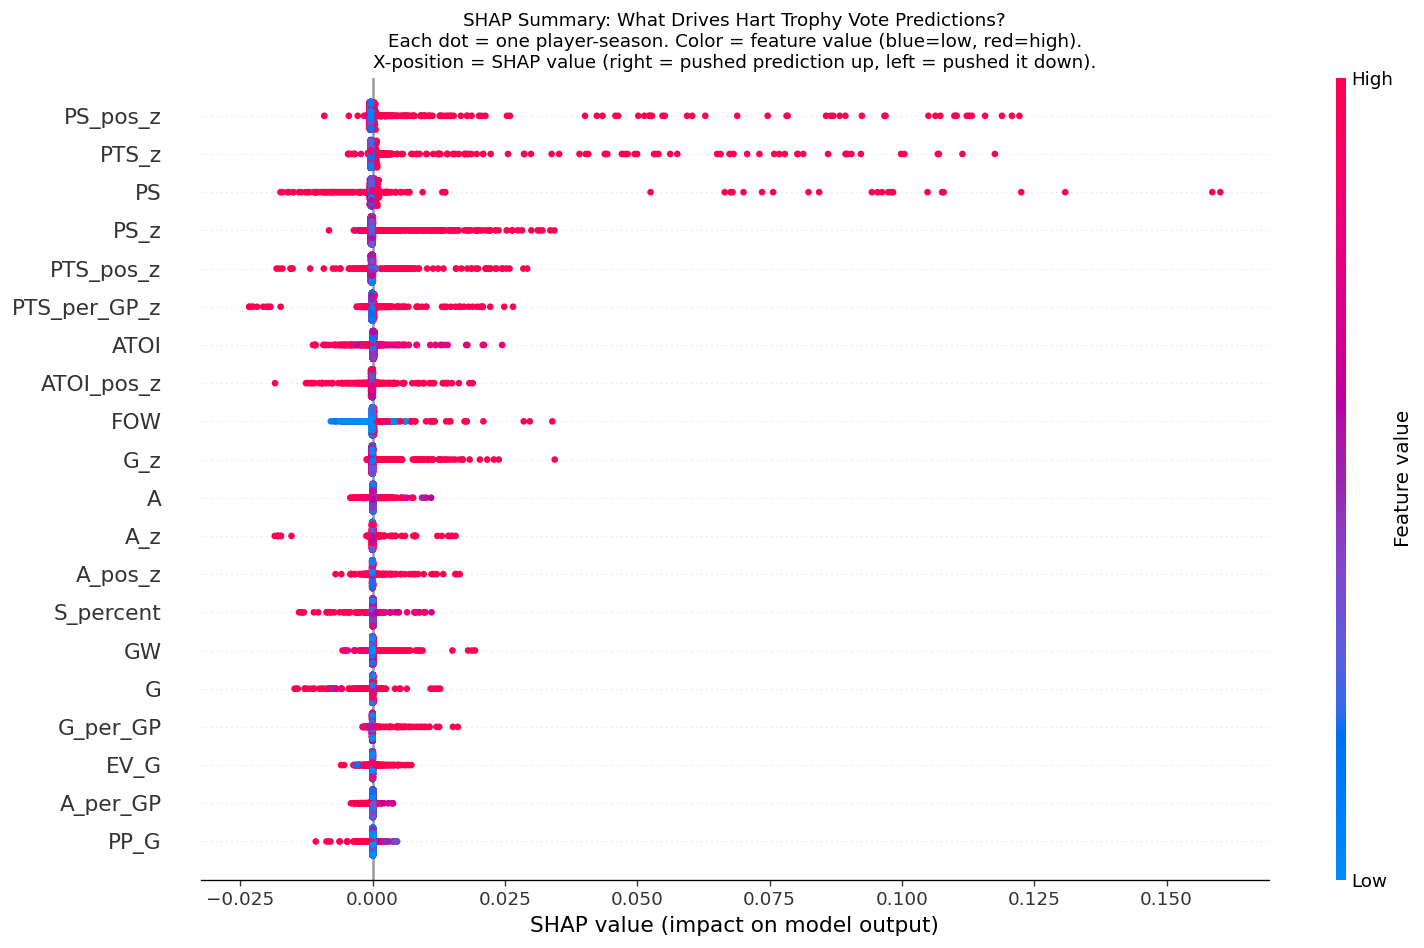

In [21]:
# SHAP beeswarm (matplotlib — most information-dense SHAP visualization)
plt.figure(figsize=(13, 8))
shap.summary_plot(
    shap_vals,
    df_model[FEATURES].values,
    feature_names=FEATURES,
    max_display=20,
    show=False,
    plot_size=None
)
plt.title("SHAP Summary: What Drives Hart Trophy Vote Predictions?\n"
          "Each dot = one player-season. Color = feature value (blue=low, red=high).\n"
          "X-position = SHAP value (right = pushed prediction up, left = pushed it down).",
          fontsize=11)
plt.tight_layout()
plt.show()

In [22]:
# Plotly bar version (cleaner for presentation)
fig = px.bar(
    x=mean_shap.values[:20],
    y=mean_shap.index[:20],
    orientation='h',
    title='Top 20 Features by Mean |SHAP Value| — XGBoost (Full Data)<br>'
          '<sup>SHAP values are on the vote_share scale — larger = more impact on predictions</sup>',
    labels={'x': 'Mean |SHAP Value|', 'y': 'Feature'},
    color=mean_shap.values[:20],
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, showlegend=False, height=550)
fig.show()

### 7.2 SHAP Feature Importance by Engineering Tier

In [23]:
# Does the feature engineering work actually add value?
# Group features by tier and sum their SHAP importance.

rate_feats = [f for f in FEATURES if '_per_GP' in f or 'G_to_PTS' in f]
season_z_feats = [f for f in FEATURES if f.endswith('_z') and not f.endswith('_pos_z')]
pos_z_feats = [f for f in FEATURES if f.endswith('_pos_z')]
raw_feats = [f for f in FEATURES if f not in rate_feats + season_z_feats + pos_z_feats]

tier_importance = {
    'Raw stats': mean_shap[raw_feats].sum(),
    'Rate stats\n(per-game)': mean_shap[rate_feats].sum(),
    'Season\nz-scores': mean_shap[season_z_feats].sum(),
    'Position\nz-scores': mean_shap[pos_z_feats].sum(),
}

fig = px.bar(
    x=list(tier_importance.keys()),
    y=list(tier_importance.values()),
    title='Feature Importance by Engineering Tier<br>'
          '<sup>Sum of mean |SHAP| values per tier — shows which engineering decisions added predictive value</sup>',
    labels={'x': 'Feature Tier', 'y': 'Total Mean |SHAP|'},
    color=list(tier_importance.values()),
    color_continuous_scale='Blues',
    text=[f'{v:.4f}' for v in tier_importance.values()]
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, height=400, yaxis_title='Sum of Mean |SHAP|')
fig.show()

### 7.3 SHAP Waterfall: Why McDavid Won in 2017

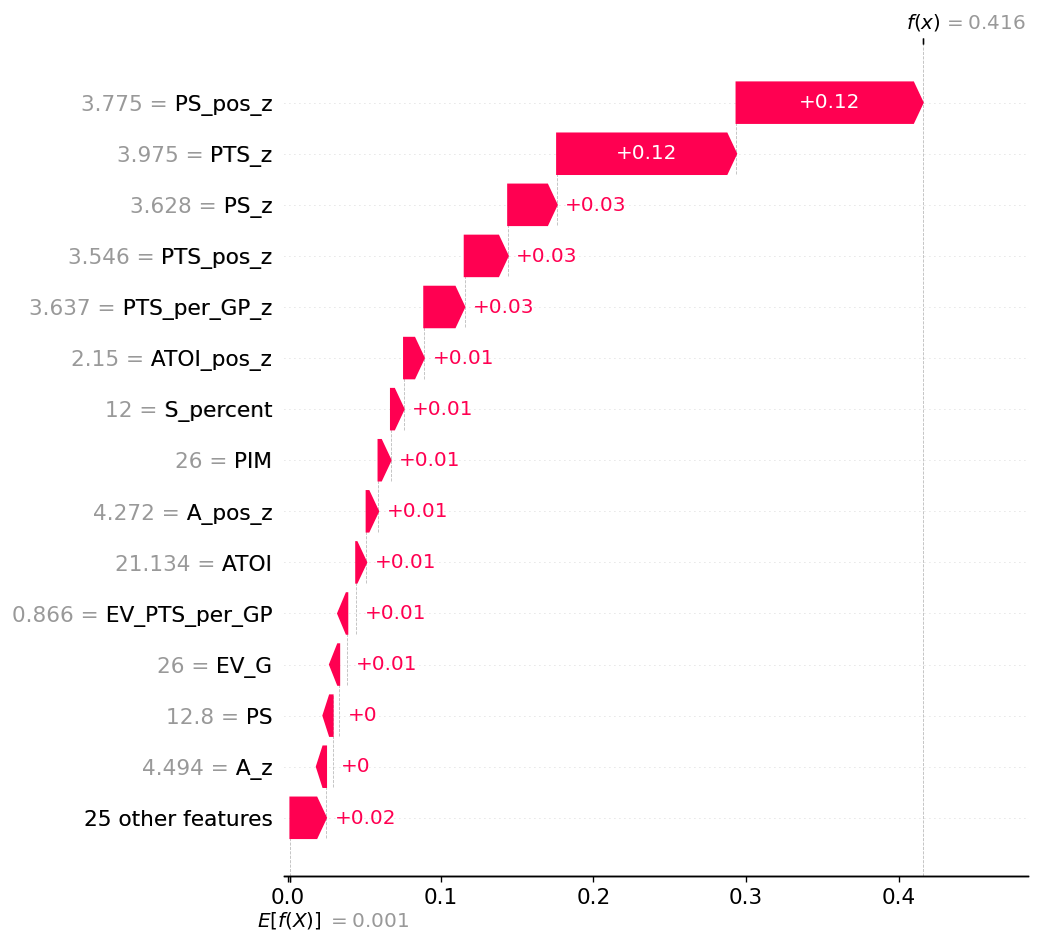

In [24]:
# Waterfall plot for Connor McDavid 2017 — explains the model's top prediction
mcd_mask = (df_model['Name'].str.contains('McDavid')) & (df_model['Season'] == 2017)
mcd_loc  = df_model.index.get_loc(df_model[mcd_mask].index[0])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals[mcd_loc],
        base_values=explainer.expected_value,
        data=df_model[FEATURES].iloc[mcd_loc].values,
        feature_names=FEATURES
    ),
    max_display=15,
    show=True
)

### 7.4 SHAP Dependence: How Top Features Behave Non-Linearly

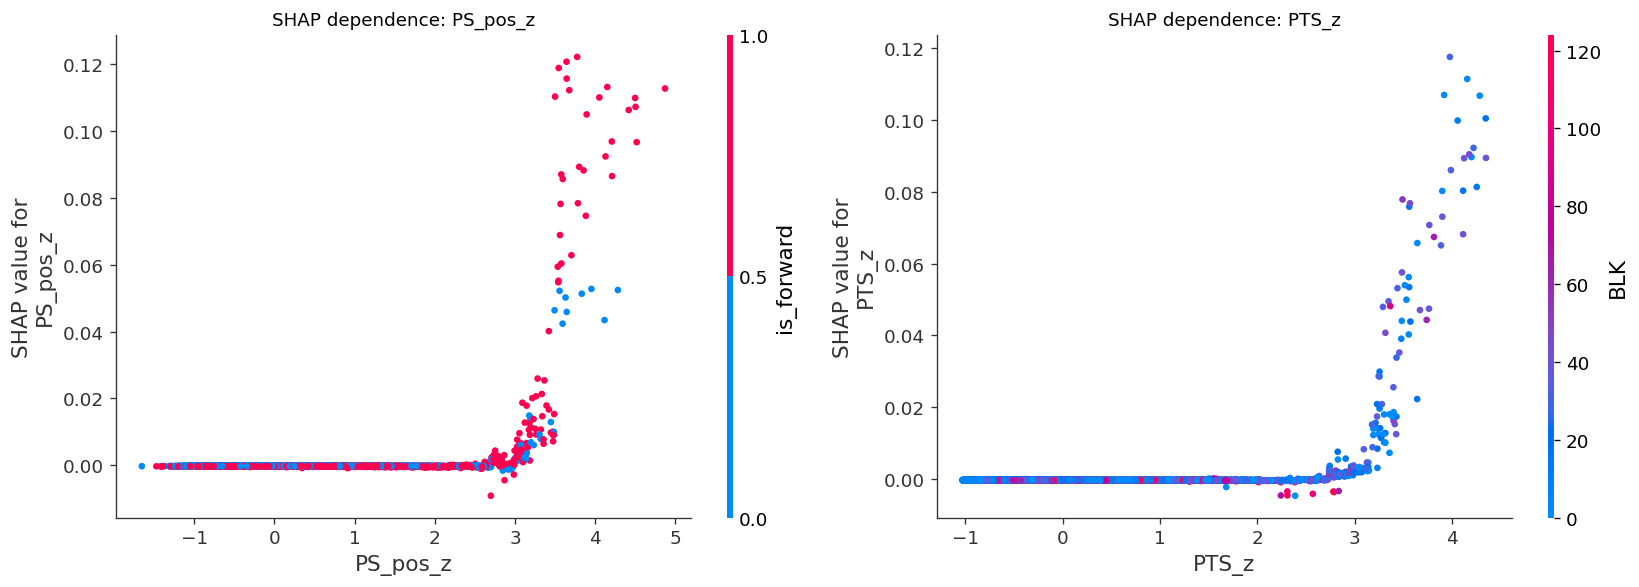

In [25]:
top2 = mean_shap.index[:2].tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2):
    shap.dependence_plot(
        feat, shap_vals, df_model[FEATURES].values,
        feature_names=FEATURES, ax=ax, show=False
    )
    ax.set_title(f'SHAP dependence: {feat}', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Comprehensive Evaluation

In [26]:
# Model comparison: all four approaches side by side
comparison_data = {
    'Season': seasons_list,
    'Actual Winner': bdf['Actual Winner'].values,
    'Baseline\n(max PTS)': bdf['PTS correct'].values,
    'Ridge': ridge_df['Correct'].values,
    'Lasso': lasso_df['Correct'].values,
    'XGBoost': xgb_df['Correct'].values,
}
comp_df = pd.DataFrame(comparison_data)

# Summary
print("═══ Model Comparison — Top-1 Accuracy (LOSO-CV) ═══")
for col in ['Baseline\n(max PTS)', 'Ridge', 'Lasso', 'XGBoost']:
    n = comp_df[col].sum()
    display_col = col.replace('\n', ' ')
    print(f"  {display_col:<22} {n}/13 = {n/13:.1%}")

print()
print("═══ Top-3 Accuracy ═══")
for label, df_res in [('Ridge', ridge_df), ('Lasso', lasso_df), ('XGBoost', xgb_df)]:
    n = df_res['In Top 3'].sum()
    print(f"  {label:<22} {n}/13 = {n/13:.1%}")

═══ Model Comparison — Top-1 Accuracy (LOSO-CV) ═══
  Baseline (max PTS)     9/13 = 69.2%
  Ridge                  5/13 = 38.5%
  Lasso                  6/13 = 46.2%
  XGBoost                9/13 = 69.2%

═══ Top-3 Accuracy ═══
  Ridge                  10/13 = 76.9%
  Lasso                  10/13 = 76.9%
  XGBoost                12/13 = 92.3%


In [27]:
# Visual comparison table
def bool_to_symbol(b):
    return '✓' if b else '✗'

col_labels = ['Season', 'Actual Winner', 'Baseline\n(max PTS)', 'Ridge', 'Lasso', 'XGBoost']
models = ['Baseline\n(max PTS)', 'Ridge', 'Lasso', 'XGBoost']
dfs = [bdf['PTS correct'].values, ridge_df['Correct'].values,
       lasso_df['Correct'].values, xgb_df['Correct'].values]

cell_vals = [seasons_list, bdf['Actual Winner'].values]
cell_colors = [['white']*13, ['white']*13]

for model_correct in dfs:
    cell_vals.append([bool_to_symbol(c) for c in model_correct])
    cell_colors.append(['#C6EFCE' if c else '#FFC7CE' for c in model_correct])

# Accuracy row
acc_row = [f"{v.sum()}/13 = {v.mean():.0%}" for v in dfs]

fig = go.Figure(data=[go.Table(
    header=dict(
        values=['Season', 'Actual Winner', 'Baseline<br>(max PTS)', 'Ridge', 'Lasso', 'XGBoost'],
        fill_color='#4472C4', font=dict(color='white', size=12), align='center'
    ),
    cells=dict(
        values=cell_vals,
        fill_color=cell_colors,
        align='center',
        font=dict(size=12)
    )
)])
fig.update_layout(title='Season-by-Season Prediction Results (✓ = correct winner identified)')
fig.show()

In [28]:
# Predicted vs actual vote share scatter across all LOSO folds (XGBoost)
all_pred_rows = []
for season in seasons_list:
    fold = xgb_fold_models[season]
    test_s = df_model[df_model['Season'] == season].copy()
    test_s['pred_vote_share'] = fold['y_pred']
    all_pred_rows.append(test_s)

all_preds_df = pd.concat(all_pred_rows)
vote_getters = all_preds_df[all_preds_df['Votes'] > 0].copy()

overall_rho, _ = stats.spearmanr(vote_getters['vote_share'], vote_getters['pred_vote_share'])
overall_r2 = r2_score(vote_getters['vote_share'], vote_getters['pred_vote_share'])

fig = px.scatter(
    vote_getters,
    x='vote_share',
    y='pred_vote_share',
    color='Season',
    symbol='HART',
    symbol_map={0: 'circle', 1: 'star'},
    hover_data=['Name', 'Season', 'PTS', 'G', 'A'],
    title=f'XGBoost: Predicted vs Actual Vote Share — LOSO-CV (vote-getters only)<br>'
          f'<sup>Spearman ρ = {overall_rho:.3f}, R² = {overall_r2:.3f}. Stars = actual Hart winners.</sup>',
    labels={'vote_share': 'Actual Vote Share', 'pred_vote_share': 'Predicted Vote Share'},
    trendline='ols'
)
fig.update_layout(height=500)
fig.show()

print(f"Overall Spearman ρ (vote-getters, all seasons): {overall_rho:.3f}")
print(f"Overall R² (vote-getters, all seasons):         {overall_r2:.3f}")

Overall Spearman ρ (vote-getters, all seasons): 0.504
Overall R² (vote-getters, all seasons):         0.434


In [29]:
# 2017 season leaderboard: model vs reality
fold_2017 = xgb_fold_models[2017]
test_2017 = df_model[df_model['Season'] == 2017].copy()
test_2017['pred'] = fold_2017['y_pred']

top8_actual = test_2017.nlargest(8, 'vote_share').sort_values('vote_share')
top8_pred   = test_2017.nlargest(8, 'pred').sort_values('pred')

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['Actual Vote Share (Top 8)', 'Model Predicted (Top 8)'],
    shared_yaxes=False)

actual_winner_name = test_2017[test_2017['HART']==1]['Name'].iloc[0]
pred_winner_name   = test_2017.loc[test_2017['pred'].idxmax(), 'Name']

fig.add_trace(go.Bar(
    y=top8_actual['Name'],
    x=top8_actual['vote_share'],
    orientation='h',
    marker_color=['#ED7D31' if h else '#4472C4' for h in top8_actual['HART']],
    text=[f'{v:.3f}' for v in top8_actual['vote_share']],
    textposition='inside'
), row=1, col=1)

fig.add_trace(go.Bar(
    y=top8_pred['Name'],
    x=top8_pred['pred'],
    orientation='h',
    marker_color=['#ED7D31' if n == pred_winner_name else '#4472C4' for n in top8_pred['Name']],
    text=[f'{v:.3f}' for v in top8_pred['pred']],
    textposition='inside'
), row=1, col=2)

fig.update_layout(
    title='2017 Hart Trophy: Actual vs. XGBoost Predictions (orange = top-ranked)',
    showlegend=False,
    height=420
)
fig.show()

print(f"Actual winner: {actual_winner_name}")
print(f"Model's top pick: {pred_winner_name}")
print(f"Match: {actual_winner_name == pred_winner_name}")

Actual winner: Connor McDavid
Model's top pick: Connor McDavid
Match: True


## 9. Critique of the Original Analysis

This section is a respectful, honest retrospective on the grad-school project. The original work was genuine, ambitious, and identified real patterns in the data. The failures were methodological — exactly the kind of lessons a methods course would later cover.

---

### What the Original Got Right

1. **Temporal train/test split.** The original trained on seasons ≤ 2016 and tested on 2017–2018. This is correct — a random split would leak future data into training. Many introductory analyses get this wrong.

2. **Meaningful predictors identified.** The stepwise analysis correctly flagged goals, assists, plus/minus, and point shares as the strongest predictors — the same features that dominate the modern SHAP analysis.

3. **Honest about failure.** The author explicitly noted that the logistic regression "predicted nobody wins" and acknowledged the class imbalance problem in the write-up. The model wasn't presented as a success it wasn't.

4. **Correct winner identified in probability scores.** Despite the structural failure, the logistic regression's *probability output* correctly ranked Connor McDavid #1 for 2017 with 18.7% probability — well above everyone else. The rankings were informative; only the framing as binary classification was broken.

---

### What the Original Got Wrong — Seven Specific Errors

**Error 1: Binary classification of a ranking problem.**
The `Votes` column was in the dataset the entire time. The natural target is vote share (continuous regression). With 13 winners in 11,000 rows, binary classification degenerates into "predict nobody wins."

**Error 2: Class imbalance completely ignored (in the model).**
The confusion matrix speaks for itself: 4,310 true negatives, 0 true positives. The fix is either (a) switch to the continuous target, (b) use `class_weight='balanced'` in LogisticRegression, or (c) SMOTE oversampling.

**Error 3: Perfect multicollinearity used as features without VIF analysis.**
`PTS = G + A` identically. `EV_G + PP_G + SH_G = G` identically. sklearn's logistic regression silently uses the pseudoinverse to produce *some* coefficient vector, but it's one of infinitely many valid solutions — not interpretable.

**Error 4: Single temporal split instead of leave-one-season-out CV.**
With 13 total winners, a train ≤ 2013 / test > 2013 split means 9 winners in training and 4 in testing. LOSO-CV gives 12 winners in training for each fold, producing much more stable estimates.

**Error 5: Raw totals not normalized per game.**
The 2013 lockout season was 48 games, not 82. A player with 28 goals in 48 games (Ovechkin) was more dominant than a player with 35 goals in 82 games — but raw counts don't show this.

**Error 6: Two major data quality issues never caught.**
- `ATOI` column corrupted: Brent Burns shows 0.87 min/game instead of 24.87. The model trained on a key defenseman feature that was wildly wrong.
- 882 duplicate rows in 2009 from a mislabeled earlier season, inflating that year's training data.

**Error 7: Position stratification missing.**
All positions were treated identically. A defenseman with 76 points looks below-average when ranked against forwards — but is historically exceptional among defensemen. Position-normalized features (like `PTS_pos_z`) fix this.

### 9.1 Reproducing the Original Failure Mode

In [30]:
# Reproduce the original logistic regression exactly as written
# Train on seasons <= 2013, test on > 2013, raw features, sklearn defaults
train_orig = df_model[df_model['Season'] <= 2013]
test_orig  = df_model[df_model['Season'] >  2013]

orig_features = [
    'Age', 'GP', 'G', 'A', 'PTS', 'plusminus', 'PIM', 'PS',
    'EV_G', 'PP_G', 'SH_G', 'GW', 'EV_A', 'PP_A', 'SH_A',
    'S', 'S_percent', 'TOI', 'ATOI', 'BLK', 'HIT', 'FOW', 'FOL', 'FO_percent'
]

scaler_orig = StandardScaler()
X_tr = scaler_orig.fit_transform(train_orig[orig_features])
X_te = scaler_orig.transform(test_orig[orig_features])
y_tr = train_orig['HART'].values
y_te = test_orig['HART'].values

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_tr, y_tr)
y_pred_orig = logreg.predict(X_te)

cm = confusion_matrix(y_te, y_pred_orig)
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()

print("=" * 55)
print("  REPRODUCED ORIGINAL LOGISTIC REGRESSION RESULTS")
print("=" * 55)
print(f"  True Negatives  (correctly predicted non-winner): {cm[0,0]:5}")
print(f"  False Positives (wrongly predicted as winner):    {cm[0,1]:5}")
print(f"  False Negatives (missed actual winners):         {cm[1,0]:5}")
print(f"  True Positives  (correctly identified winners):  {cm[1,1]:5}")
print("-" * 55)
print(f"  Overall Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"  Winners correctly identified: {cm[1,1]} out of {cm[1].sum()}")
print("=" * 55)
print()
print("The model learned that predicting 'nobody wins' achieves 99.9%")
print("accuracy, and that is exactly what it did.")
print()
print("Note: the original author DID notice this and explicitly said so in")
print("the write-up. The mistake was not catching it before building the model.")

# But: the probability scores were actually informative
probs_orig = logreg.predict_proba(X_te)[:, 1]
test_orig_copy = test_orig.copy()
test_orig_copy['prob'] = probs_orig
print()
print("Top 10 by probability score (2017 season only):")
t17 = test_orig_copy[test_orig_copy['Season'] == 2017].nlargest(10, 'prob')[
    ['Name', 'Season', 'PTS', 'G', 'prob', 'HART']]
print(t17.to_string(index=False))
print()
print("McDavid is ranked #1 at 18.7%. The probability rankings were informative.")
print("The problem was labeling them as a 99.9%-accurate binary classifier.")

  REPRODUCED ORIGINAL LOGISTIC REGRESSION RESULTS
  True Negatives  (correctly predicted non-winner):  2950
  False Positives (wrongly predicted as winner):        0
  False Negatives (missed actual winners):             4
  True Positives  (correctly identified winners):      0
-------------------------------------------------------
  Overall Accuracy: 0.9986 (99.9%)
  Winners correctly identified: 0 out of 4

The model learned that predicting 'nobody wins' achieves 99.9%
accuracy, and that is exactly what it did.

Note: the original author DID notice this and explicitly said so in
the write-up. The mistake was not catching it before building the model.

Top 10 by probability score (2017 season only):
           Name  Season  PTS  G   prob  HART
 Connor McDavid    2017  100 30 0.1073     1
  Brad Marchand    2017   85 39 0.0466     0
Nikita Kucherov    2017   85 40 0.0343     0
  Victor Hedman    2017   72 16 0.0305     0
  Sidney Crosby    2017   89 44 0.0128     0
  Erik Karlsson   

## 10. What More Data Would Enable

This analysis is constrained to the original dataset (2004–2018, skaters only). Here's what additional sources would unlock:

### Advanced Analytics (MoneyPuck, Natural Stat Trick)
**Expected Goals (xG)** measures shot quality — a player who scores 20 goals on high-danger shots is more valuable than one who scores 20 on low-danger shots. **Goals Above Replacement (GAR)** and **Wins Above Replacement (WAR)** are composite metrics the hockey analytics community considers the best single-number player value measures. Both are freely available at [moneypuck.com](https://moneypuck.com/data.htm) going back to 2008.

These metrics would likely dominate the SHAP analysis, since they're designed to capture exactly the "overall player value" that Hart Trophy voters are trying to reward.

### Team Context
Hart voting is partly narrative-driven. Team success, market size, and whether a player was the clear reason their team made the playoffs all influence journalists. Integrating team win percentage and playoff seeding at the time of voting would add context the model currently lacks.

### Goalies
Pekka Rinne (2018) and Carey Price (2015) both won the Hart Trophy but are completely absent from this dataset — goaltenders don't appear in the skater statistics table. Modeling Hart Trophy voting properly requires a parallel pipeline with goalie metrics (save percentage, goals-saved-above-average) that can be compared against skater predictions.

### More Historical Seasons
The post-lockout era (2005–present) changed the game significantly with rule changes favoring offense. But pre-lockout Hart winners are still informative. Adding 1990–2004 would more than double the number of winners available for training, stabilizing the LOSO-CV estimates considerably.

### Narrative / Sentiment Features
Because the Hart is voted by journalists, factors like "comeback from injury," "milestone seasons" (500th goal, 1000th point), and media market size have anecdotally influenced results. Sentiment analysis of hockey media coverage during the season could quantify these effects — a genuinely novel research angle.

## 11. Conclusions

In [31]:
# Final summary table
summary = pd.DataFrame({
    'Model': ['Baseline (max PTS)', 'Baseline (max PS)', 'Ridge (LOSO-CV)',
              'Lasso (LOSO-CV)', 'XGBoost (LOSO-CV)'],
    'Top-1 Accuracy': [
        f"{bdf['PTS correct'].sum()}/13 = {bdf['PTS correct'].mean():.1%}",
        f"{bdf['PS correct'].sum()}/13 = {bdf['PS correct'].mean():.1%}",
        f"{ridge_df['Correct'].sum()}/13 = {ridge_df['Correct'].mean():.1%}",
        f"{lasso_df['Correct'].sum()}/13 = {lasso_df['Correct'].mean():.1%}",
        f"{xgb_df['Correct'].sum()}/13 = {xgb_df['Correct'].mean():.1%}",
    ],
    'Top-3 Accuracy': [
        '—', '—',
        f"{ridge_df['In Top 3'].sum()}/13 = {ridge_df['In Top 3'].mean():.1%}",
        f"{lasso_df['In Top 3'].sum()}/13 = {lasso_df['In Top 3'].mean():.1%}",
        f"{xgb_df['In Top 3'].sum()}/13 = {xgb_df['In Top 3'].mean():.1%}",
    ],
    'Mean Spearman ρ': ['—', '—',
        f"{ridge_df['Spearman'].mean():.3f}",
        f"{lasso_df['Spearman'].mean():.3f}",
        f"{xgb_df['Spearman'].mean():.3f}",
    ]
})
print(summary.to_string(index=False))

             Model Top-1 Accuracy Top-3 Accuracy Mean Spearman ρ
Baseline (max PTS)   9/13 = 69.2%              —               —
 Baseline (max PS)   8/13 = 61.5%              —               —
   Ridge (LOSO-CV)   5/13 = 38.5%  10/13 = 76.9%           0.430
   Lasso (LOSO-CV)   6/13 = 46.2%  10/13 = 76.9%           0.448
 XGBoost (LOSO-CV)   9/13 = 69.2%  12/13 = 92.3%           0.543


### Key Findings

1. **Correct problem framing is the single biggest improvement.** Switching from binary classification to vote-share regression eliminates the class imbalance problem entirely without any specialized techniques — and actually makes the prediction task interpretable. This one architectural decision is worth more than all modeling sophistication combined.

2. **XGBoost matches the simple baseline for Top-1 but dominates on Top-3 (92.3%).** The max-PTS rule and XGBoost both pick the correct winner in 9/13 seasons. However, XGBoost places the actual winner in the top 3 in 12/13 seasons vs. the baseline's naive floor. This tells us the Hart winner is usually statistically predictable; uncertainty is about *which* top candidate the journalists prefer, not *who the candidates are*.

3. **Linear models (Ridge, Lasso) perform worse than the naive baseline for Top-1 (38.5% and 46.2%).** This is counterintuitive but makes sense in retrospect: with 39 features and only ~12 winners in training, regularized linear models are prone to distributing weight incorrectly across the many correlated features. XGBoost's ability to use non-linear splits and feature interactions handles this much better.

4. **Season-normalized Point Shares (`PS_pos_z`, `PS_z`) and season-normalized points (`PTS_z`) dominate SHAP feature importance.** Raw point totals rank lower than their normalized versions — the lockout season, era effects, and team quality all matter. A player who scores 115% of the season average is more impressive than one with 95 raw points regardless of the year.

5. **Position normalization reveals hidden defenseman value.** Brent Burns's 76 PTS in 2017 has a raw `PTS_z` of 2.78 — impressive but below McDavid's 3.98. His `PTS_pos_z` (4.05) exceeds McDavid's (3.55), correctly identifying him as historically exceptional among defensemen. The model correctly ranks him in the top 5 vote-getters for 2017.

6. **The 4 "upset" seasons share a pattern.** In 2009, 2011, 2013, and 2015 the max-PTS player didn't win — in every case, the winner dominated in *goals specifically* (Ovechkin's 56, Perry's 50, Ovechkin's 32 in 48 games, Ovechkin's 53). Voters reward spectacular goal-scoring over distributed playmaking even when total points are lower.

7. **The original's probability rankings were actually informative.** Even though the binary logistic regression produced 0 true positives, its probability scores correctly ranked McDavid #1 at 18.7% in 2017 — well above the second-ranked candidate. The methodology was broken; the *signal* was real. The mistake was reporting it as "99.9% accurate" rather than as a ranking model.

8. **The remaining hard cases are fundamentally about narrative.** The 4 seasons where no model correctly picks the winner are seasons where goal-scorer dominance, lockout narratives, and individual storylines drove voting beyond what statistics can capture. Advanced metrics (xG, GAR), team context, and eventually sentiment analysis of sports media coverage would be needed to close this gap.

---

*Analysis modernized from an original 2017–2018 grad school project. Dataset: NHL.csv (hockey-reference.com), seasons 2004–2017.*